# Задача определения количества подразделений при наилучшей дислокации (LSCP)

В общем виде процесс решения задачи определения количества подразделений при наилучшей дислокации можно представить следующим образом:

```{mermaid}
flowchart LR

  model("**МОДЕЛИРОВАНИЕ
          ПАРАМЕТРОВ
          ПРИБЫТИЯ**")
  
  result["**РЕЗУЛЬТАТЫ**"]

  analyze("**АНАЛИЗ**
        ---
        Время прибытия
        ---
        Индекс прикрытия")

  metrics["**МЕТРИКИ**"]

  lscp_add["**LSCP**
        ---
        ADD"]

  lscp_common["**LSCP**
        ---
        LSCP_Common"]

  blp_algs["**ЭВРИСТИЧЕСКИЕ АЛГОРИТМЫ MCLP**
        ---
        GNS, GA, SAA, GA+GNS"]

  blp("**ВЫБОР ДИСЛОКАЦИИ**")

  aim["ЦЕЛЬ РАСЧЕТА"]


  model --> result
  metrics --> analyze
  result --> analyze
  blp_algs --> lscp_common
  lscp_common --> blp
  lscp_add --> blp
  analyze --> blp
  aim --> blp
  blp --> model

```

Решение задачи определения количества подразделений при наилучшей дислокации в **Генезис** осуществляется на основании двух подходов:

1. Решение за одну итерацию (единым алгоритмом)
2. Решение в несколько итераций решения задачи MCLP - на каждой итерации решается задача MCLP, после чего проверяется достигнута ли цель расчета. Если цель не достигнута, добавляется новая ПСЧ и выполняется следующая итерация MCLP.


В **Генезис** реализованы следующие алгоритмы решения задачи LSCP:

- Рекомендуемый:
  - `genesis.lscp.LSCP_ADD` -- Алгоритм жадного добавления (ADD) - *рекомендуемый*, реализующий первый подход
- Прочие:
  - `genesis.lscp.LSCP_Common` -- Общий модульный алгоритм, реализующий второй подход. 



Реализован также ряд дополнительных алгоритмов описываемых в разделе **Для разработчиков**.

## Загрузка исходных данных

In [1]:
import numpy as np
import osmnx as ox
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import genesis as genesis


# Версии библиотек
print('OSMnx:', ox.__version__,
      '\nGeoPandas:', gpd.__version__,
      '\nPandas:', pd.__version__,
      '\ngenesis:', genesis.__version__,
      )

OSMnx: 2.0.1 
GeoPandas: 1.0.1 
Pandas: 2.2.2 
genesis: 0.1.034


In [2]:
from graphs.speeds import set_graph_travel_times, kmh_to_mm
from fire_units.settings import DEFAULT_SPEEDS


# 1. Загрузка исходных данных
## Загрузка ГДС
G = ox.load_graphml('data/kemerovo/gds.ml')

## Установка скоростного режима
set_graph_travel_times(
    G,
    speeds=DEFAULT_SPEEDS,
    morph_function = kmh_to_mm)

## Упрощение графа (уменьшение количества узлов)
G = ox.simplification.simplify_graph(G)

## Загрузка границ города
borders = gpd.read_file('data/kemerovo/borders.gpkg')

## Загрузка пожарных подразделений
units = gpd.read_file('data/kemerovo/fire_units.gpkg')
### Сопоставление пожарных подразделений с ближайшими узлами ГДС
units['node'] = ox.distance.nearest_nodes(G, units.geometry.x, units.geometry.y)
### Формирование словаря подразделений для передачи алгоритму
units_dict = {k:v for k,v in zip(units['node'], units['name'])}

## Загрузка зданий
buildings = gpd.read_file('data/kemerovo/buildings.gpkg')
### Сопоставление зданий с ближайшими узлами ГДС
centroids = ox.projection.project_gdf(buildings).geometry.centroid
buildings['node'] = ox.distance.nearest_nodes(ox.project_graph(G), 
                                              centroids.x,
                                              centroids.y
                                              )

## Рекомендуемый способ: Алгоритм жадного добавления

Рекомендуемым способом является использование алгоритма жадного добавления **ADD**: `genesis.lscp.LSCP_ADD`.

Данный подход универсален и может быть применен к решению задач **BLP**, **MCLP**, **LSCP**.

Он основан на идее определения точки при размещении пожарного депо в которой обеспечивается заданное время прибытия к как можно большему количеству объектов защиты. При расчете используется моделирование параметров прибытия подразделений пожарной охраны с использованием матрицы прибытия `genesis.states.ArrivalTimeMatrixState`.

### Матрица прибытия {.unnumbered}

In [4]:
from genesis.states import get_atm

## Расчет матрицы прибытия
matrix = get_atm(G,
                 data             = buildings,
                 data_sample_size = 4000,
                 cutoff           = 10,
                 )

|########################################| 100.0%


### Определение количества и оптимальной дислокации ПСЧ с целью достижения ИП-10 = 95%, без учета имеющихся подразделений. {.unnumbered}

Подразделений: 1  ИП-10: 30.345342144532083
Подразделений: 2  ИП-10: 53.67991899381795
Подразделений: 3  ИП-10: 61.985717331059476
Подразделений: 4  ИП-10: 68.3276486889789
Подразделений: 5  ИП-10: 74.62161586015775
Подразделений: 6  ИП-10: 80.07088040929439
Подразделений: 7  ИП-10: 84.81933489661053
Подразделений: 8  ИП-10: 87.27350245150288
Подразделений: 9  ИП-10: 89.91952675335749
Подразделений: 10  ИП-10: 91.57429119590705
Подразделений: 11  ИП-10: 93.54881688339373
Подразделений: 12  ИП-10: 95.62460029844382
ИТОГ:
Подразделений: 12  ИП-10: 95.62460029844382


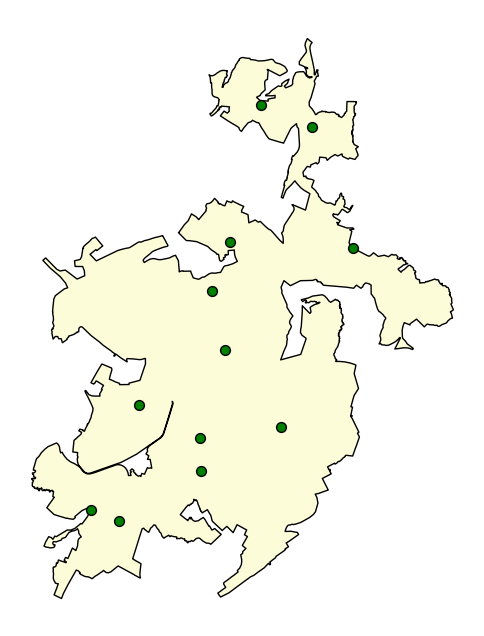

In [5]:
from genesis.lscp import LSCP_ADD
from genesis.states import FirstArrivalUnitState
from fire_units.metrics import CoverIndexBuilding


# 2. Сборка решения
## Выбор алгоритма моделирования параметров прибытия
state = FirstArrivalUnitState()

## Выбор метрики
metric = CoverIndexBuilding(buildings, ip_val=10) # Используется метрика ИП-10. Для ADD метрика выполняет роль оценки

## Функция остановки
stop_case = lambda value, **kwargs: value >= 95      # Расчет проводится для достижения ИП-10 = 95%

## Функция выполняемая при добавлении новой ПСЧ
after_mclp = lambda best_metric, dynamic_nodes, **kwargs: print('Подразделений:', len(dynamic_nodes), ' ИП-10:', best_metric)

## Сборка и инициализация алгоритма ADD
add = LSCP_ADD(  
    state_function      = state,
    matrix              = matrix,
    metric_function     = metric,
    stop_case_function  = stop_case,
    after_mclp_function = after_mclp,
)


# 3. Расчет BLP
best_nodes, best_metric = add(
        env          = G,
    )


# 4. Печать результатов
print('ИТОГ:')
print('Подразделений:', len(best_nodes), ' ИП-10:', best_metric)

## Получение набора данных узлов графа, для сопоставления с полученным лучшим узлом
g_nodes = ox.graph_to_gdfs(G, edges=False)

## Печать карты
fig, ax = plt.subplots(figsize=(8,8))
borders.plot(ax=ax, color='#fcfcd9', edgecolor='black')
g_nodes.loc[best_nodes.keys()].plot(ax=ax, facecolors='g', edgecolors='k', markersize=50)
ax.set_axis_off()
plt.show()

### Определение количества и оптимальной дислокации ПСЧ с целью достижения ИП-10 = 98%, с учетом имеющихся подразделений. {.unnumbered}

Подразделений: 1  ИП-10: 80.98219995736517
Подразделений: 2  ИП-10: 86.44745256874867
Подразделений: 3  ИП-10: 90.54839053506716
Подразделений: 4  ИП-10: 93.01055212108292
Подразделений: 5  ИП-10: 94.9850778085696
Подразделений: 6  ИП-10: 97.0741846088254
Подразделений: 7  ИП-10: 97.64442549562993
Подразделений: 8  ИП-10: 98.43849925389043
ИТОГ:
Подразделений: 8  ИП-10: 98.43849925389043


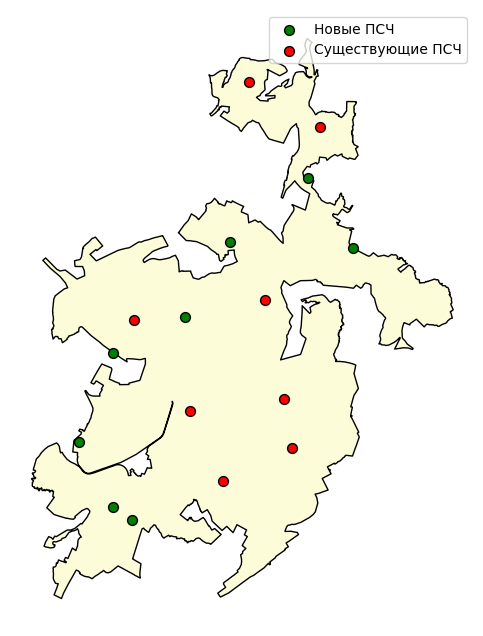

In [10]:
from genesis.lscp import LSCP_ADD
from genesis.states import FirstArrivalUnitState
from fire_units.metrics import CoverIndexBuilding


# 2. Сборка решения
## Выбор алгоритма моделирования параметров прибытия
state = FirstArrivalUnitState()

## Выбор метрики
metric = CoverIndexBuilding(buildings, ip_val=10) # Используется метрика ИП-10. Для ADD метрика выполняет роль оценки

## Функция остановки
stop_case = lambda value, **kwargs: value >= 98      # Расчет проводится для достижения ИП-10 = 98%

## Функция выполняемая при добавлении новой ПСЧ
after_mclp = lambda best_metric, dynamic_nodes, **kwargs: print('Подразделений:', len(dynamic_nodes), ' ИП-10:', best_metric)

## Сборка и инициализация алгоритма ADD
add = LSCP_ADD(  
    state_function      = state,
    matrix              = matrix,
    metric_function     = metric,
    stop_case_function  = stop_case,
    after_mclp_function = after_mclp,
)


# 3. Расчет BLP
best_nodes, best_metric = add(
        env          = G,
        static_nodes = units_dict,
    )


# 4. Печать результатов
print('ИТОГ:')
print('Подразделений:', len(best_nodes), ' ИП-10:', best_metric)

## Получение набора данных узлов графа, для сопоставления с полученным лучшим узлом
g_nodes = ox.graph_to_gdfs(G, edges=False)

## Печать карты
fig, ax = plt.subplots(figsize=(8,8))
borders.plot(ax=ax, color='#fcfcd9', edgecolor='black')
g_nodes.loc[best_nodes.keys()].plot(ax=ax, facecolors='g', edgecolors='k', markersize=50, label='Новые ПСЧ')
g_nodes.loc[units_dict.keys()].plot(ax=ax, facecolors='r', edgecolors='k', markersize=50, label='Существующие ПСЧ')
ax.set_axis_off()
plt.legend()
plt.show()

## Дополнительные способы (Общий модульный алгоритм)

### Применение алгоритма Генезис {.unnumbered}

In [ ]:
from fire_units.best_points import BestNodeHillClimbing_HD_Max_Mean
from genesis.lscp import LSCPCommon
from genesis.mclp import BestNodesKoptG
from genesis.point_selectors import GenesisNodeSelector
from genesis.states import FirstArrivalUnitState
from fire_units.metrics import CoverIndexBuilding


# 1. Исходные данные
## Определение стартового размещения (произвольным образом) для 3 подразделений
g_nodes_list = list(G.nodes())
start_dict = {
    g_nodes_list[1000]: 'псч-1',
    g_nodes_list[2000]: 'псч-2',
    g_nodes_list[3000]: 'псч-3',
}


# 2. Сборка решения
## Выбор алгоритма моделирования параметров прибытия
state = FirstArrivalUnitState()

## Выбор метрики
metric = CoverIndexBuilding(buildings, ip_val=10) # Используется метрика ИП-10. Для ADD метрика выполняет роль оценки

## Функция остановки
stop_case = lambda value, **kwargs: value >= 95      # Расчет проводится для достижения ИП-10 = 95%

## Функция выполняемая при добавлении новой ПСЧ
after_mclp = lambda best_metric, dynamic_nodes, **kwargs: print('Подразделений:', len(dynamic_nodes), ' ИП-10:', best_metric)

## Функция определения места предварительного размещения новой ПСЧ на каждой итерации
selector = GenesisNodeSelector(state, metric)

## Используемый алгоритм MCLP - в данном случае GNS
mclp = BestNodesKoptG(  
    state_function      = state,
    metric_function     = metric,
    best_point_function = BestNodeHillClimbing_HD_Max_Mean(state, metric),
)


## Сборка и инициализация алгоритма ADD
lscp = LSCPCommon(
    mclp_function       = mclp,             # Функция MCLP
    point_selector      = selector,         # Функция определения места предварительного размещения новой ПСЧ на каждой итерации
    stop_case_function  = stop_case,        # Функция остановки
    metric_function     = metric,           # Расчетная метрика
    names_pattern       = 'НОВАЯ ПСЧ №{}',  # Шаблон наименования новых ПСЧ
    start_names_index   = 3,                # Стартовый номер ПСЧ (Наименования существующих и создаваемых ПСЧ не могут повторяться!)
    after_mclp_function = after_mclp,       # Функция выполняемая после каждой итерации MCLP
)


# 3. Расчет BLP
best_nodes, best_metric = lscp(
        env          = G,
        dynamic_nodes= start_dict,
        # static_nodes = units_dict,
    )

### Применение гибрида Генетический алгоритм + Генезис (GA+GNS) {.unnumbered}

In [ ]:
from fire_units.best_points import BestNodeHillClimbing_HD_Max_Mean
from fire_units.mclp import BestNodesGAKopt
from genesis.lscp import LSCPCommon
from genesis.mclp import BestNodesKoptG
from genesis.point_selectors import GenesisNodeSelector
from genesis.states import FirstArrivalUnitState
from fire_units.metrics import CoverIndexBuilding


# 1. Исходные данные
## Определение стартового размещения (произвольным образом) для 3 подразделений
g_nodes_list = list(G.nodes())
start_dict = {
    g_nodes_list[1000]: 'псч-1',
    g_nodes_list[2000]: 'псч-2',
    g_nodes_list[3000]: 'псч-3',
}


# 2. Сборка решения
## Выбор алгоритма моделирования параметров прибытия
state = FirstArrivalUnitState()

## Выбор метрики
metric = CoverIndexBuilding(buildings, ip_val=10) # Используется метрика ИП-10. Для ADD метрика выполняет роль оценки

## Функция остановки
stop_case = lambda value, **kwargs: value >= 95      # Расчет проводится для достижения ИП-10 = 95%

## Функция выполняемая при добавлении новой ПСЧ
after_mclp = lambda best_metric, dynamic_nodes, **kwargs: print('Подразделений:', len(dynamic_nodes), ' ИП-10:', best_metric)

## Функция определения места предварительного размещения новой ПСЧ на каждой итерации
selector = GenesisNodeSelector(state, metric)

## Используемый алгоритм MCLP - в данном случае гибрид GA+GNS
## Функция печати хода расчета по итогам эпохи
epoch_end = lambda epoch, best_metric, **kwargs: print(f'Эпоха: {epoch}, Метрика: {best_metric}')

## Алгоритм Генезис
gns = BestNodesKoptG(  
    state_function      = state,
    metric_function     = metric,
    best_point_function = BestNodeHillClimbing_HD_Max_Mean(state, metric),
    iterations          = 3,
)

## гибрид GA+GNS
mclp = BestNodesGAKopt(  
    state_function      = state,
    metric_function     = metric,
    kopt_function       = gns,              # Функция Генезис
    epochs              = 15,               # Кол-во эпох
    node_selector       = selector,
    epoch_end_function  = epoch_end,        # Вывод хода расчета по итогам эпохи
)


## Сборка и инициализация алгоритма ADD
lscp = LSCPCommon(
    mclp_function       = mclp,             # Функция MCLP
    point_selector      = selector,         # Функция определения места предварительного размещения новой ПСЧ на каждой итерации
    stop_case_function  = stop_case,        # Функция остановки
    metric_function     = metric,           # Расчетная метрика
    names_pattern       = 'НОВАЯ ПСЧ №{}',  # Шаблон наименования новых ПСЧ
    start_names_index   = 3,                # Стартовый номер ПСЧ (Наименования существующих и создаваемых ПСЧ не могут повторяться!)
    after_mclp_function = after_mclp,       # Функция выполняемая после каждой итерации MCLP
)


# 3. Расчет BLP
best_nodes, best_metric = lscp(
        env          = G,
        dynamic_nodes= start_dict,
        # static_nodes = units_dict,
    )